<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">Datos Masivos II · PRÁCTICA 1</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Sección Uno: Clasificación de Cáncer</div><div style="opacity:.72;font-size:14px;margin-top:6px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div></div>

## Instrucciones 
Realizar una comparación entre: PCA, Non Negative Matrix y TSNE con los conjuntos de datos dados, así como una visualización de estos. 
Además, generar un clasificador o identificación de patrones, según sea el caso.


<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0. Contexto. Clasificación Molecular de Cancer: Descubrimiento y Predicción de Clases a través del monitoreo de Expresión Genética. </span></div>

La Problemática abordada en la presente sección de esta práctica se basa en el artículo de Golub et al. (1999), "Molecular Classification of Cancer: Class Discovery and Class Prediction by Gene Expression Monitoring", el cual aborda el problema de clasificar tipos de cáncer a partir de perfiles de expresión genética.
Localmente, esto se realiza través del descubrimiento de **nuevas clases** y la **predicción de clases**. 
Donde con descubrimiento nos referimos a identificar subtipos de cáncer no reconocidos previamente, agrupando tumores con base en similitudes en su expresión genética. Por otro lado, con predicción nos referimos a que, dado un conjunto de muestras ya etiquetado, se pueda asignar una etiqueta a nuevas muestras.

Esto es relevante porque permitiría: 
* Generar un **test único de clasificación**
* Desarrollar **técnicas más generales** que faciliten diagnósticos más específicos
* Mejorar el tratamiento del paciente **maximizando eficacia y minimizando toxicidad**
* **Superar las limitaciones de un diagnóstico basado únicamente en la morfología del tumor**, dado que tumores con apariencia similar pueden seguir cursos clínicos muy distintos.

Los datos con los que trabajan son expresiones génicas de pacientes con ALL y AML (**Leucemia Linfoblástica Aguda y Leucemia Mieloide Aguda** , ya clasificados clínicamente). A lo largo del artículo se aborda la metodología para ambos problemas: para el discovery, se usan self-organizing maps (SOM) para agrupar los tumores sin conocer sus etiquetas de antemano; para la prediction, se construye un clasificador mediante un sistema de votos ponderados, apoyado en un análisis previo de relevancia de genes (los más correlacionados con la distinción entre clases).

<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0.1 Los Datos </span></div>

* golub1999.pdf: artículo original en formato no estructurado para documentación. 
* **actual.csv**: datos estructurados con etiquetas de clase (ALL / AML) por paciente.
* **dataset_ALL_AML_train.csv y dataset_ALL_AML_independent.csv**: conjuntos de expresión génica (entrenamiento e independiente, respectivamente, replicando la división usada en el artículo original para validación).


<div style="border-left:4px solid #524e64;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Preparación de Entorno  </span></div>

In [2]:
#Instalación de Bibliotecas 
#! pip install numpy pandas scikit-learn matplotlib seaborn plotly scipy

In [65]:
#Importación de Bibliotecas

# Manejo de datos
import numpy as np
import pandas as pd
import math as mt 

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Reducción de dimensionalidad
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE

# Clasificación 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import NMF
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

# Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, classification_report,
    ConfusionMatrixDisplay
)
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.cm as cm

In [66]:
import sys
!{sys.executable} -m pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]



In [4]:
import sys
!{sys.executable} -m pip install nbformat --upgrade

In [5]:
#Lectura de Datos en DataFrame

df_i = pd.read_csv('data_set_ALL_AML_independent.csv')
df_t = pd.read_csv('data_set_ALL_AML_train.csv')
df_etiquetas = pd.read_csv('actual.csv')

display(df_i.sample(5))
display(df_t.sample(5))
display(df_etiquetas.tail(5))

,Gene Description,Gene Accession Number,39,call,40,call.1,42,call.2,47,call.3,...,65,call.29,66,call.30,63,call.31,64,call.32,62,call.33
5919,VASOACTIVE INTESTINAL POLYPEPTIDE RECEPTOR 1 P...,X77777_s_at,-321,A,-383,A,-161,A,-359,A,...,-281,A,-276,A,-61,A,-653,A,-391,A
3604,Lysophospholipase homolog (HU-K5) mRNA,U67963_at,366,P,326,P,593,P,550,P,...,489,A,391,P,851,P,1707,P,481,P
3076,Selenium donor protein (selD) mRNA,U34044_at,161,A,106,A,51,A,60,A,...,191,M,-95,A,238,P,94,A,162,A
6165,GB DEF = C-sis proto-oncogene,X83705_s_at,741,A,698,A,351,A,523,A,...,596,A,291,A,803,A,1149,A,743,A
1996,Ras inhibitor mRNA; 3' end,M37190_at,205,A,11,A,45,A,6,A,...,150,A,67,A,171,A,254,A,187,A


,Gene Description,Gene Accession Number,1,call,2,call.1,3,call.2,4,call.3,...,29,call.33,30,call.34,31,call.35,32,call.36,33,call.37
6175,BCL2 B-cell CLL/lymphoma 2,M13994_s_at,146,A,175,A,318,A,65,A,...,11,A,72,A,311,A,509,A,329,A
3981,WD repeat protein HAN11 mRNA,U94747_at,-116,A,-74,A,99,A,69,A,...,402,P,-783,A,-39,A,-226,A,43,A
5766,B-CELL ANTIGEN RECEPTOR COMPLEX ASSOCIATED PRO...,X13451_s_at,-175,A,-60,A,-143,A,-228,A,...,25,A,-89,A,-141,A,9,A,138,A
2309,GB DEF = Pyruvate dehydrogenase complex (PDHA2...,M86808_at,75,A,19,A,55,A,7,A,...,37,A,-11,A,10,P,19,A,77,A
4382,GB DEF = HB2A gene for high sulfur keratin,X63337_at,268,A,193,P,281,P,241,P,...,146,A,190,P,228,A,277,A,305,A


,patient,cancer
67,68,ALL
68,69,ALL
69,70,ALL
70,71,ALL
71,72,ALL


Observaciones iniciales 

1. dataset_ALL_AML_train.csv: 
- Contiene las muestras del **conjunto de entrenamiento inicial** del artículo de Golub et al. (1999): pacientes numerados del **1 al 38** (27 ALL más 11 AML).
- Cada muestra/paciente tiene **dos columnas asociadas**: una con el **valor numérico de expresión génica** y otra llamada **call**.
- La columna call es la **"detection call"** de Affymetrix, e indica la confiabilidad de la lectura de expresión para ese gen en esa muestra:
  - `P` (*Present*): gen detectado con confianza.
  - `A` (*Absent*): señal indistinguible del ruido de fondo.
  - `M` (*Marginal*): caso ambiguo.
- Las columnas Gene Description y Gene Accession Number identifican cada gen.

2. dataset_ALL_AML_independent.csv:
- Contiene las muestras del **conjunto independiente** usado por Golub et al. para validar el predictor ya entrenado: pacientes numerados del **39 al 72** (34 muestras en total).
- Misma estructura que el dataset de entrenamiento: columnas pareadas de **valor numérico y call** por paciente.
- **No hay pacientes repetidos** entre este archivo y dataset_ALL_AML_train.csv  (son dos grupos de pacientes distintos, correspondientes a las dos etapas de validación descritas en el artículo: validación cruzada sobre el conjunto inicial, y prueba final sobre el conjunto independiente).

3.  actual.csv:
- Contiene las **72 muestras totales** (38 del train más 34 del independiente), cada una con su **etiqueta de clase** (ALL o AML).
- Actúa como archivo maestro que permite unir ambos datasets de expresión mediante el número de paciente.


**Nota importante** especto a la **orientación** de los dos primeros datasets: 


 Dado que las **filas representan genes** y las **columnas representan pacientes** (más sus respectivas columnas call), la orientación está **transpuesta** respecto a la convención establecida: las filas deberían ser las muestras/pacientes y las columnas los features/genes. 

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. Selección de datos</span></div>


Se conservan **todas las columnas** de ambos datasets en esta etapa exploratoria, pues: 
- Respecto a data_set_ALL_AML_train y data_set_ALL_AML_independent la columna call aporta información sobre la confiabilidad de cada medición y la columna de expresión numérica es la medición en sí; aunado a esta, la descripción de los genes nos aporta información para conocimiento de dominio que puede ser valiosa en la interpretación. 
- Actual.csv por otro lado nos indica la clasificación de cada paciente para poder validar. 

**Formato de datos**


Por la anotación de la sección de observaciones iniciales se traspondrá el orden de las filas y columnas de los dataframes, sin embargo antes de transponer, se separaránn las columnas de expresión numérica de las columnas call en dos dataframes distintos (df_expr_t y df_calls_t).
 Esto se hizo porque:
  - Mezclar valores numéricos (expresión) y categóricos (call: P/A/M) en una sola matriz dificulta el perfilado y el tipado correcto de columnas.
  - call no es una variable biológica del paciente, sino una bandera de confiabilidad de la medición por gen con lo que  su naturaleza y tratamiento son distintos a los de la expresión genética en sí. 

- Ambos dataframes resultantes comparten el **mismo índice** (pacientes) y **mismas columnas** (genes, identificados por Gene Accession Number). 

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Análisis Exploratorio </span></div>

In [6]:
# Separación de las columnas de expresión numérica de las columnas call en dos dataframes distintos.Trasposición posterior. 
def separar_y_transponer(df):
    """
    Separa las columnas de expresión numérica y las columnas call,
    y transpone el dataframe de expresión para que las filas sean
    pacientes y las columnas sean genes.

    Args:
        df (pd.DataFrame): DataFrame original con genes como filas y
            columnas alternadas de expresión numérica y 'call' por paciente.

    Returns:
        tuple:
            - df_expr_t (pd.DataFrame): expresión transpuesta
              (filas = pacientes, columnas = genes, identificadas por
              'Gene Accession Number').
            - df_calls_t (pd.DataFrame): columnas 'call' transpuestas,
              con la misma estructura (filas = pacientes, columnas = genes).
    """
    # Identificadores de gen (se usarán como nombres de columna tras transponer)
    gene_ids = df['Gene Accession Number']

    # Columnas de expresión numérica
    cols_call = [c for c in df.columns if c.startswith('call')]
    cols_expr = [c for c in df.columns if c not in ('Gene Description', 'Gene Accession Number')
             and c not in cols_call]

    df_expr = df[cols_expr].copy()
    df_calls = df[cols_call].copy()

    # Transposición de los dataframes para que las filas sean pacientes y las columnas sean genes
    df_expr_t = df_expr.T
    df_expr_t.columns = gene_ids
    df_expr_t.index.name = 'paciente'

    df_calls_t = df_calls.T
    df_calls_t.columns = gene_ids
    df_calls_t.index.name = 'paciente'

    return df_expr_t, df_calls_t


In [7]:
#Aplicamos función anterior a nuestros dataframes de entrenamiento e independiente para obtener los dataframes de expresión y call transpuestos.
df_expr_train, df_calls_train = separar_y_transponer(df_t)
df_expr_indep, df_calls_indep = separar_y_transponer(df_i)

In [8]:
#Verificación de transposición y separación de dataframe train
print(df_expr_train.shape)
df_expr_train.head()


(38, 7129)


Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
paciente,,,,,,,,,,,,,,,,,,,,,
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [9]:
print(df_expr_indep.shape)
df_expr_indep.head()

(34, 7129)


Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
paciente,,,,,,,,,,,,,,,,,,,,,
39,-342,-200,41,328,-224,-427,-656,-292,137,-144,...,277,1023,67,214,-135,1074,475,48,168,-70
40,-87,-248,262,295,-226,-493,367,-452,194,162,...,83,529,-295,352,-67,67,263,-33,-33,-21
42,22,-153,17,276,-211,-250,55,-141,0,500,...,413,399,16,558,24,893,297,6,1971,-42
47,-243,-218,-163,182,-289,-268,-285,-172,52,-134,...,174,277,6,81,2,722,170,0,510,-73
48,-130,-177,-28,266,-170,-326,-222,-93,10,159,...,233,643,51,450,-46,612,370,29,333,-19


Una vez con los datos en el formato correcto, realizamos perfilado 

In [10]:
def perfilado_general_muestra(df, n_muestra=30, random_state=42):
    """
    Genera un perfilado exploratorio de un DataFrame de alta dimensionalidad,
    mostrando boxplots de una muestra aleatoria de columnas numéricas.

    Args:
        df (pd.DataFrame): DataFrame a perfilar 
        n_muestra (int): número de columnas numéricas a graficar en los
            boxplots. Default 30.
        random_state (int): semilla para la selección aleatoria de columnas,
            para reproducibilidad.

    Returns:
        None: la función imprime y despliega los resultados directamente
        (no retorna ningún objeto).
    """
    n, m = df.shape
    print(f'Número de registros: {n}')
    print(f'Número de columnas: {m}')
    print('-' * 100)
    print(f'Valores nulos: {df.isna().sum().sum()}')
    print(f'Valores duplicados: {df.duplicated().sum()}')
    print('-' * 100)

    cols_numericas = df.select_dtypes(include=('float64', 'int64')).columns
    cols_muestra = pd.Series(cols_numericas).sample(
        n=min(n_muestra, len(cols_numericas)), random_state=random_state
    )

    print(f'Mostrando boxplots de una muestra aleatoria de {len(cols_muestra)} '
          f'de {len(cols_numericas)} columnas numéricas totales.')

    col_num = len(cols_muestra)
    plt.figure(figsize=(12, mt.ceil(col_num / 5) * 2.5))
    for i, column in enumerate(cols_muestra):
        plt.subplot(mt.ceil(col_num / 5), 5, i + 1)
        plt.boxplot(df[column])
        plt.title(column, fontsize=8)
    plt.tight_layout()
    plt.show()

    print('Estadísticas descriptivas:')
    display(df[cols_muestra].describe())

Número de registros: 38
Número de columnas: 7129
----------------------------------------------------------------------------------------------------
Valores nulos: 0


Valores duplicados: 0
----------------------------------------------------------------------------------------------------
Mostrando boxplots de una muestra aleatoria de 30 de 7129 columnas numéricas totales.


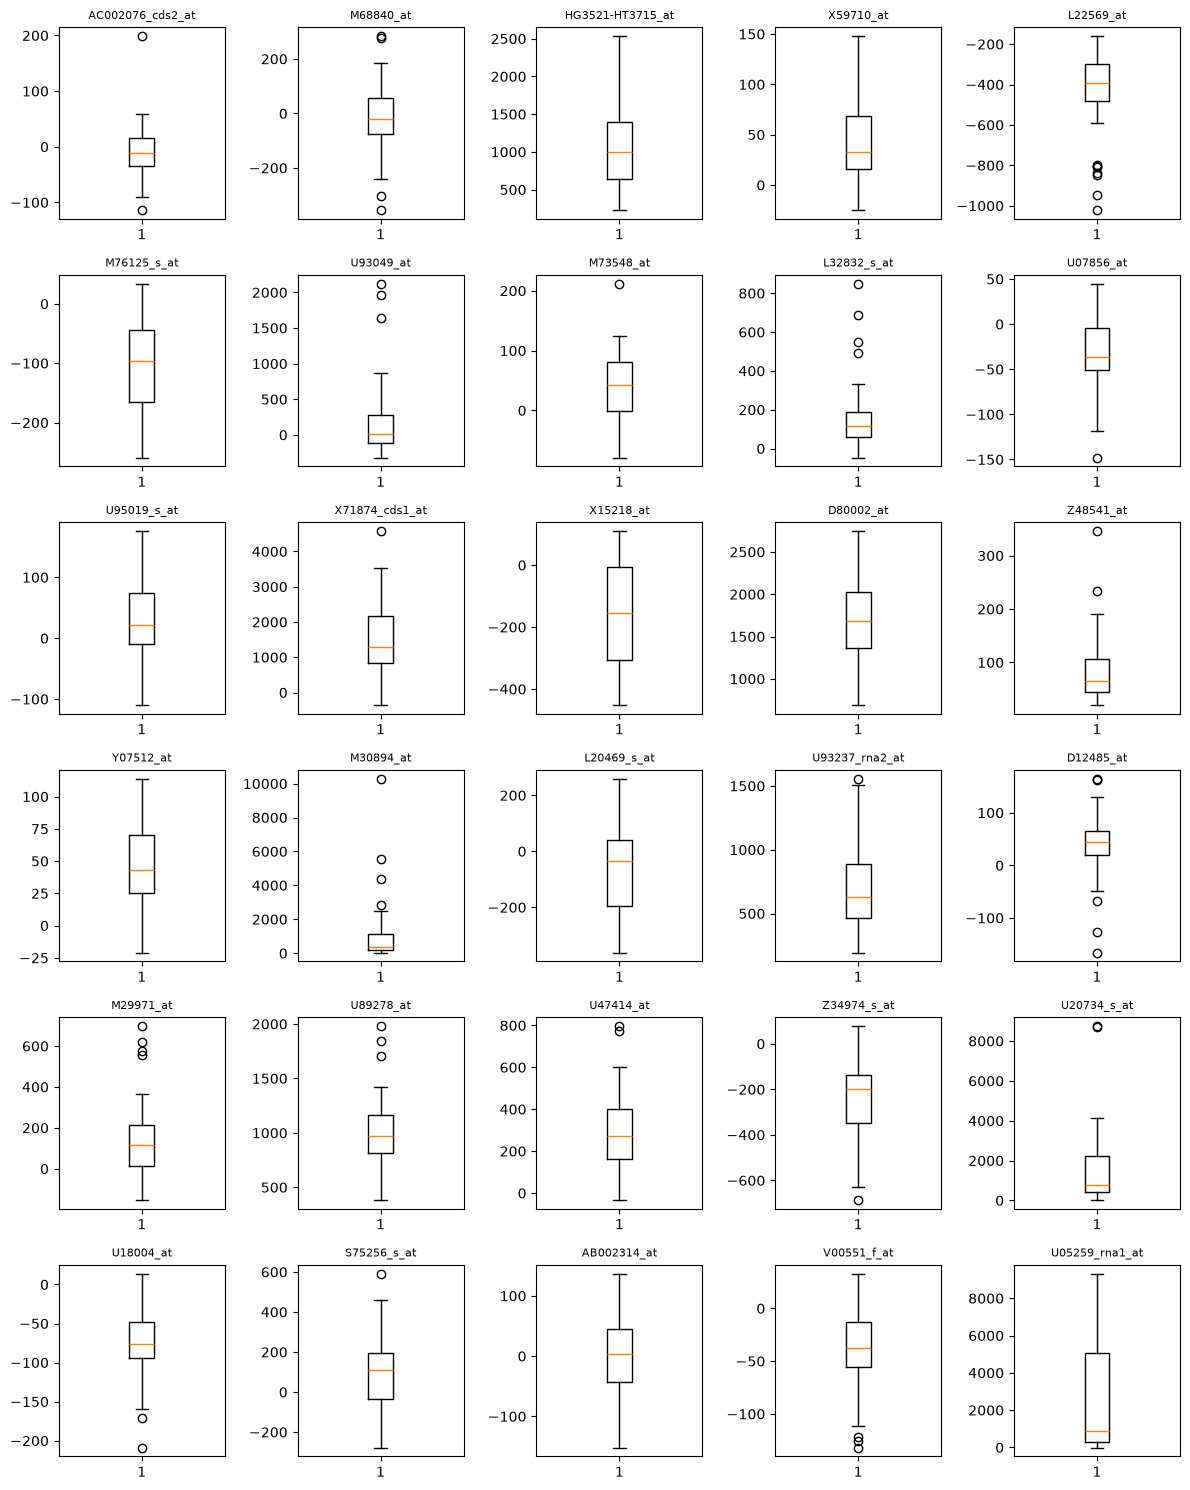

Estadísticas descriptivas:


Gene Accession Number,AC002076_cds2_at,M68840_at,HG3521-HT3715_at,X59710_at,L22569_at,M76125_s_at,U93049_at,M73548_at,L32832_s_at,U07856_at,...,M29971_at,U89278_at,U47414_at,Z34974_s_at,U20734_s_at,U18004_at,S75256_s_at,AB002314_at,V00551_f_at,U05259_rna1_at
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,-9.105263,-13.210526,1110.421053,40.394737,-451.026316,-102.868421,191.368421,43.447368,169.421053,-30.894737,...,155.842105,1023.342105,296.578947,-240.368421,1635.184211,-76.157895,99.289474,0.289474,-39.842105,2614.973684
std,52.387222,137.638217,600.344119,38.285937,222.927753,77.848491,571.284632,54.296333,191.748094,43.768302,...,199.808358,330.497028,193.407095,199.409726,2069.731512,47.919711,184.453159,67.322503,40.442503,2739.455050
min,-114.000000,-355.000000,228.000000,-25.000000,-1022.000000,-259.000000,-320.000000,-79.000000,-47.000000,-148.000000,...,-154.000000,382.000000,-34.000000,-687.000000,11.000000,-209.000000,-278.000000,-152.000000,-132.000000,-14.000000
25%,-34.000000,-73.750000,641.250000,15.500000,-484.000000,-165.000000,-114.000000,-1.750000,60.500000,-50.750000,...,13.750000,816.000000,164.750000,-348.500000,433.750000,-94.000000,-35.250000,-42.750000,-55.500000,288.000000
50%,-11.000000,-21.500000,1004.500000,32.500000,-393.500000,-95.500000,15.000000,42.500000,117.000000,-36.500000,...,114.000000,972.500000,272.500000,-199.000000,752.000000,-76.000000,112.000000,3.500000,-38.000000,882.500000
75%,15.500000,55.000000,1399.000000,68.750000,-300.250000,-43.500000,285.250000,80.500000,190.000000,-4.000000,...,215.000000,1167.750000,400.750000,-135.750000,2236.750000,-48.000000,196.500000,45.250000,-13.000000,5073.750000
max,199.000000,284.000000,2535.000000,148.000000,-160.000000,34.000000,2124.000000,212.000000,850.000000,45.000000,...,698.000000,1981.000000,797.000000,78.000000,8752.000000,14.000000,592.000000,137.000000,33.000000,9326.000000


In [11]:
#Perfilado de dataframe de expresión de entrenamiento
perfilado_general_muestra(df_expr_train)

Número de registros: 34
Número de columnas: 7129
----------------------------------------------------------------------------------------------------
Valores nulos: 0
Valores duplicados: 0
----------------------------------------------------------------------------------------------------
Mostrando boxplots de una muestra aleatoria de 30 de 7129 columnas numéricas totales.


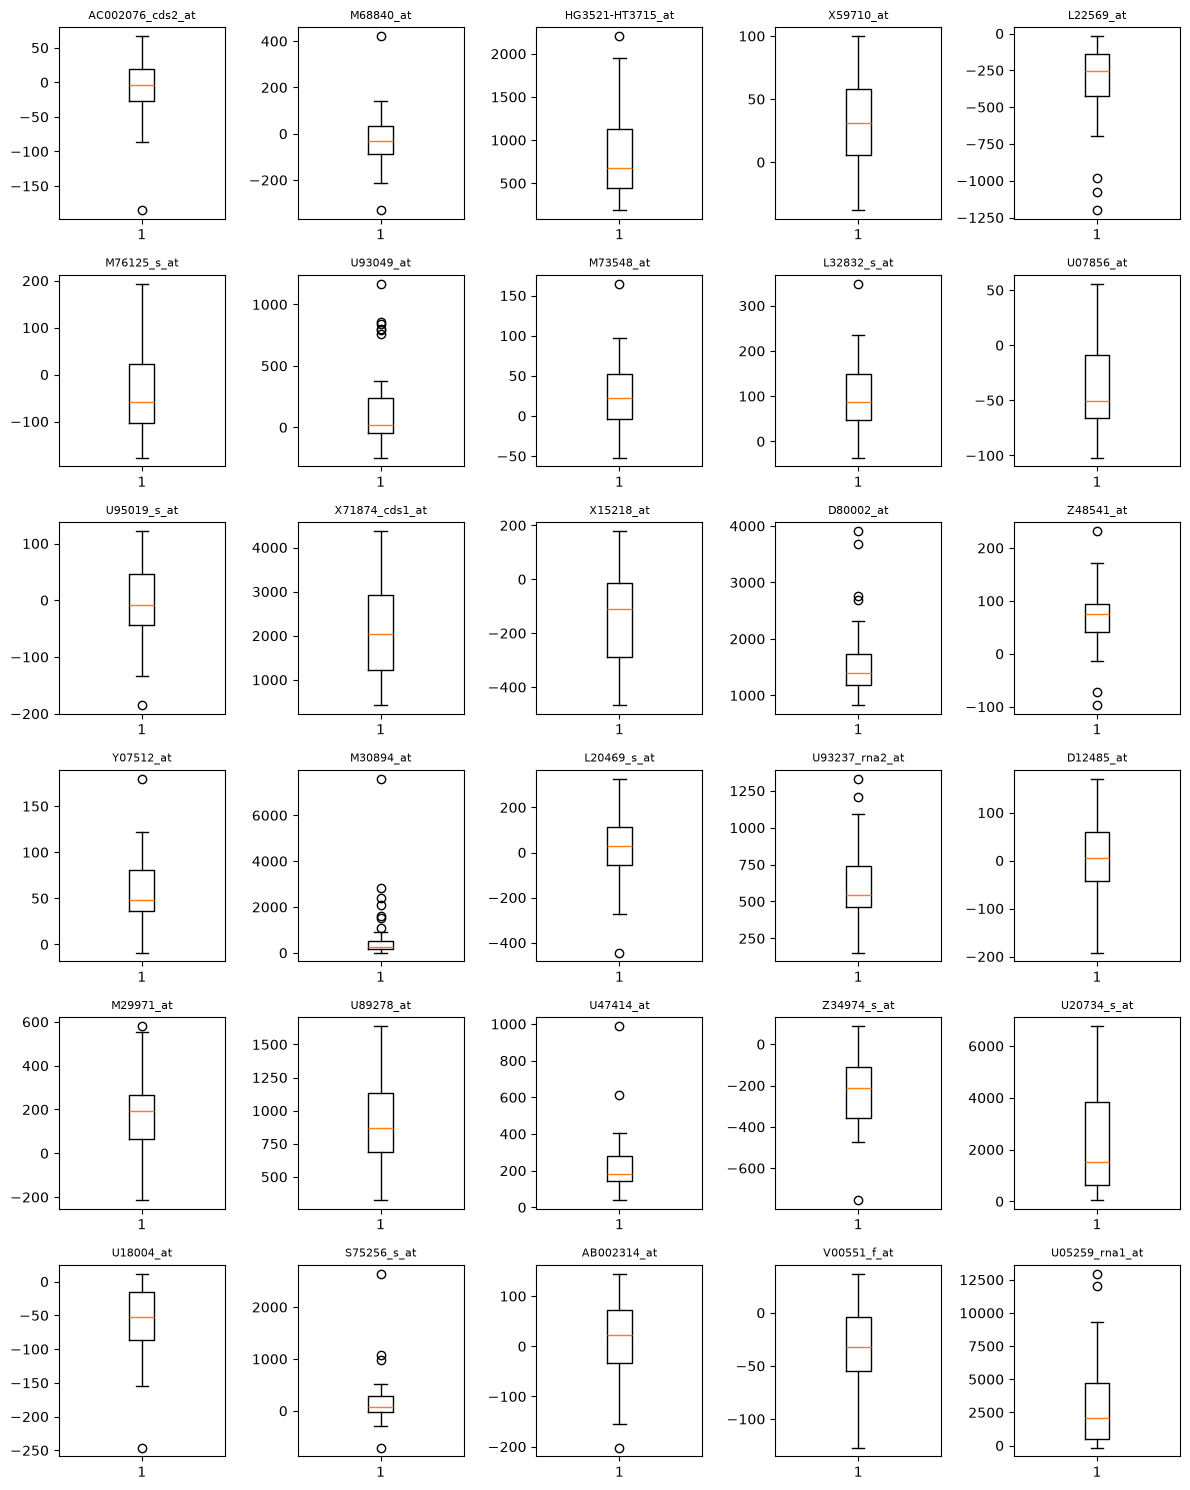

Estadísticas descriptivas:


Gene Accession Number,AC002076_cds2_at,M68840_at,HG3521-HT3715_at,X59710_at,L22569_at,M76125_s_at,U93049_at,M73548_at,L32832_s_at,U07856_at,...,M29971_at,U89278_at,U47414_at,Z34974_s_at,U20734_s_at,U18004_at,S75256_s_at,AB002314_at,V00551_f_at,U05259_rna1_at
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,...,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,-9.000000,-24.441176,846.941176,33.676471,-346.970588,-34.676471,172.617647,25.500000,100.000000,-36.735294,...,170.088235,890.058824,240.058824,-244.058824,2229.588235,-59.205882,201.000000,12.794118,-33.088235,3132.705882
std,48.647153,126.681943,507.721705,32.796637,288.633718,89.236397,356.845949,48.498828,83.542767,42.483729,...,191.904706,351.343995,181.141990,173.702103,1922.110411,56.825506,543.925407,89.553363,37.492114,3320.779149
min,-185.000000,-330.000000,188.000000,-38.000000,-1200.000000,-177.000000,-247.000000,-52.000000,-36.000000,-102.000000,...,-214.000000,324.000000,39.000000,-755.000000,45.000000,-246.000000,-710.000000,-202.000000,-127.000000,-160.000000
25%,-26.750000,-88.750000,449.250000,5.500000,-422.500000,-102.750000,-43.250000,-4.000000,46.500000,-66.250000,...,66.250000,689.500000,143.750000,-356.750000,626.250000,-86.250000,-31.250000,-33.000000,-55.250000,500.750000
50%,-4.500000,-32.000000,680.500000,31.000000,-256.500000,-58.500000,17.000000,22.500000,87.000000,-51.000000,...,191.500000,868.500000,179.500000,-210.500000,1533.500000,-53.000000,78.500000,22.000000,-32.500000,2047.500000
75%,19.500000,35.000000,1130.000000,58.250000,-141.500000,23.000000,240.000000,52.750000,149.250000,-9.250000,...,266.500000,1130.250000,281.500000,-110.000000,3838.250000,-16.000000,280.750000,72.500000,-4.000000,4721.000000
max,67.000000,422.000000,2206.000000,100.000000,-17.000000,194.000000,1170.000000,165.000000,349.000000,56.000000,...,581.000000,1639.000000,989.000000,88.000000,6771.000000,12.000000,2646.000000,145.000000,37.000000,12968.000000


In [12]:
#Pefilado de dataframe de expresión independiente
perfilado_general_muestra(df_expr_indep)

In [13]:
#Se guarda información de columnas 
cols_numericas = df_expr_train.select_dtypes(include=('float64', 'int64')).columns
cols_muestra = pd.Series(cols_numericas).sample(n=30, random_state=42)

In [14]:
#Para ver si existe algún patrón de separabilidad, se plotean boxplot por clase 
def boxplots_genes_por_clase(genes, df_expr, df_etiquetas, cols=5):
    """
    Genera una cuadrícula de boxplots comparando la distribución de expresión
    por clase (ALL vs AML) para una lista de genes.

    Args:
        genes (list): lista de identificadores de gen (Gene Accession Number).
        df_expr (pd.DataFrame): dataframe de expresión transpuesto
            (filas = pacientes, columnas = genes).
        df_etiquetas (pd.DataFrame): dataframe con columnas 'patient' y
            'cancer'.
        cols (int): número de columnas en la cuadrícula de subplots.

    Returns:
        None: la función despliega los boxplots directamente.
    """
    datos = df_expr[genes].copy()
    datos.index = datos.index.astype(int)
    datos = datos.merge(df_etiquetas, left_index=True, right_on='patient')

    n = len(genes)
    filas = mt.ceil(n / cols)
    plt.figure(figsize=(cols * 3, filas * 3))

    for i, gene_id in enumerate(genes):
        grupos = [
            datos.loc[datos['cancer'] == clase, gene_id]
            for clase in datos['cancer'].unique()
        ]
        plt.subplot(filas, cols, i + 1)
        plt.boxplot(grupos, tick_labels=datos['cancer'].unique())
        plt.title(gene_id, fontsize=8)

    plt.tight_layout()
    plt.show()

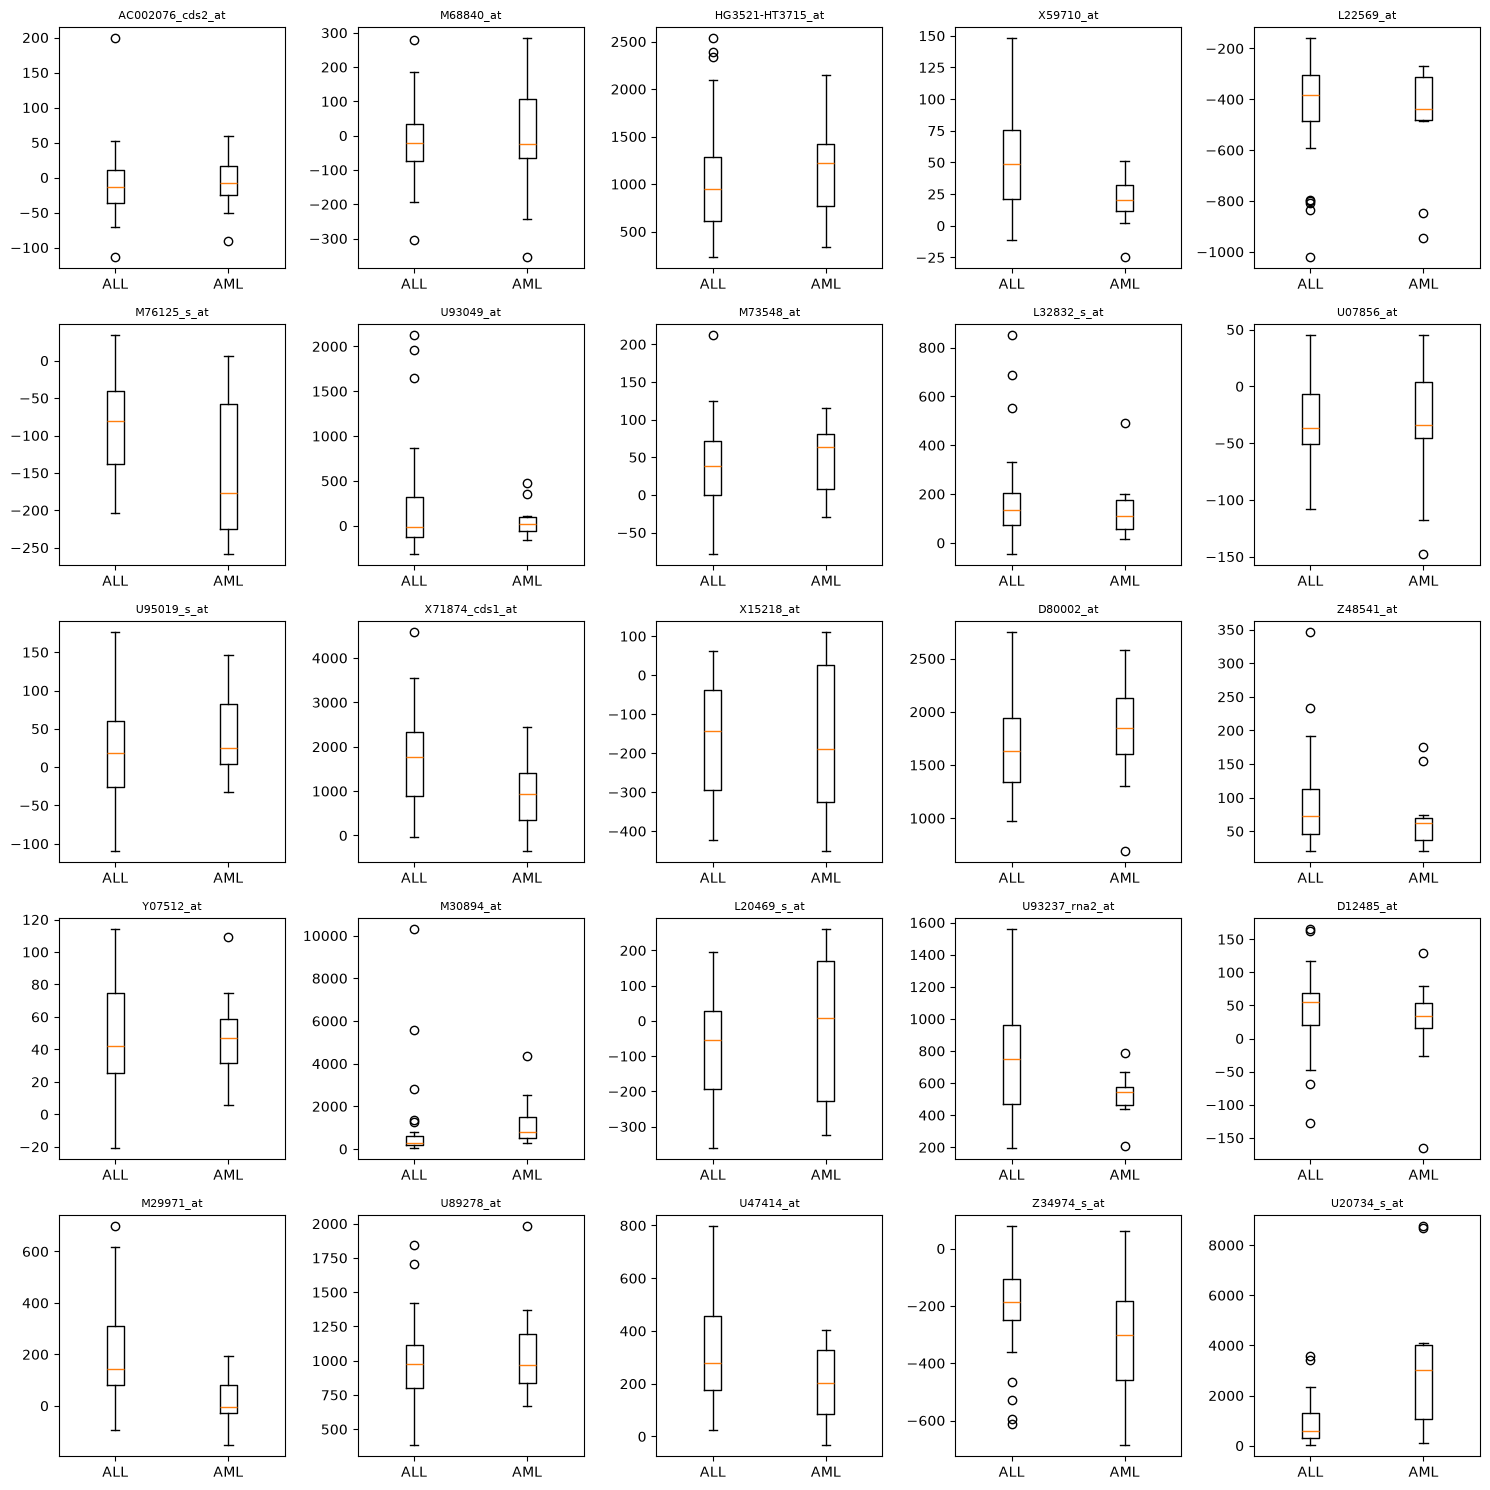

In [15]:
boxplots_genes_por_clase(cols_muestra[:25].tolist(), df_expr_train, df_etiquetas)

Observaciones: 

 1. Boxplots de expresión por clase

- Se generaron boxplots comparando la distribución de expresión (ALL vs AML) 
  para una muestra aleatoria de 25 genes (de los 7129 totales), como primer 
  acercamiento visual a la separabilidad entre clases.
- **No se observa separabilidad marcada entre ALL y AML** en la mayoría de 
  los genes de la muestra: las medianas de ambas clases están cercanas y las 
  cajas se solapan considerablemente en casi todos los casos.
- Esto es consistente con lo reportado en Golub et al. (1999): de los 6817 
  genes analizados en el artículo original, solo 1100 mostraron una 
  correlación con la distinción AML-ALL mayor a la esperada por azar 
  (*neighborhood analysis*). Es decir, la gran mayoría de genes no son 
  discriminantes por sí solos. 
- Se observan sesgos y outliers puntuales en varias distribuciones, pero 
  ninguno concluyente para diferenciar clases sin un criterio de selección 
  de genes informativos.

2. Diferencias en estadísticos: 

- Los estadísticos descriptivos de la muestra de genes 
  muestran **escalas muy dispares** entre columnas: por ejemplo, 
  AC002076_cds2_at tiene media ≈ -9 y desviación estándar ≈ 50, mientras 
  que U05259_rna1_at tiene media ≈ 2600-3300 y desviación estándar del 
  mismo orden de magnitud. Esta disparidad de escalas confirma la necesidad de **estandarizar los 
  datos**.



Solo como nota extra, como equipo observamos la necesidad de  un método de selección de genes informativos (neighborhood analysis) en  lugar de usar todos los genes por igual. 

3. No hay datos nulos o duplicados
4. Se observan genes con expresiones negativas



El análisis anterior fue genérico, sin embargo el artículo menciona que hay genes altamente correlacionados con los diferentes tipos de cancer, por tal se buscará cuáles son estos genes. 

In [16]:
#Separación por clase de los dataframes de expresión de entrenamiento

df_expr_train_idx = df_expr_train.copy()
df_expr_train_idx.index = df_expr_train_idx.index.astype(int)

pacientes_all = df_etiquetas.loc[df_etiquetas['cancer'] == 'ALL', 'patient']
pacientes_aml = df_etiquetas.loc[df_etiquetas['cancer'] == 'AML', 'patient']

expr_all = df_expr_train_idx.loc[df_expr_train_idx.index.isin(pacientes_all)]
expr_aml = df_expr_train_idx.loc[df_expr_train_idx.index.isin(pacientes_aml)]

print(expr_all.shape, expr_aml.shape)  

(27, 7129) (11, 7129)


In [17]:
#Prueba t de dos muestras

t_stat, p_valor = stats.ttest_ind(expr_all, expr_aml, axis=0, equal_var=False)

df_ttest = pd.DataFrame({
    'gen': df_expr_train_idx.columns,
    't_stat': t_stat,
    'p_valor': p_valor
})

df_ttest_ordenado = df_ttest.sort_values('p_valor')
df_ttest_ordenado.head(15)

,gen,t_stat,p_valor
5771,U22376_cds2_s_at,7.904300,8.388715e-09
4327,X59417_at,6.803106,9.821652e-08
2019,M55150_at,-8.091951,2.472593e-07
6280,M31211_s_at,6.293715,2.917295e-07
1305,L13278_at,6.281410,3.251349e-07
5592,D26156_s_at,6.097113,5.184004e-07
2353,M92287_at,6.217365,6.826528e-07
6470,U09087_s_at,6.120221,7.413020e-07
2641,U05259_rna1_at,6.181656,1.314936e-06
4534,X74262_at,6.016513,1.488034e-06


T-test vectorizado: genes con mayor separación ALL vs AML

- Se aplicó un t-test de Welch de forma vectorizada sobre las 7129 columnas (genes) de df_expr_train, 
  comparando las medias de expresión entre pacientes ALL (n=27) y AML (n=11).

Fundamento matemático: 
Pruebas de hipótesis. 

- **Hipótesis nula (H₀):** la media de expresión de un gen dado es la misma 
  en pacientes ALL y en pacientes AML. 
- **Hipótesis alternativa (H₁):** la media de expresión del gen difierere entre ALL y AML.
- **Qué mide el p-valor:** la probabilidad de observar una diferencia de medias mayor a la observada, *asumiendo que H₀ es cierta* . Un p-valor pequeño indica que esa diferencia es poco probable por azar, 
- **Estadístico t:** 
  $$t = \frac{\text{diferencia de medias entre grupos}}{\text{variabilidad esperada de esa diferencia por azar}}$$
  Un |t| grande indica que la diferencia observada excede ampliamente lo esperable por ruido de muestreo, lo cual se traduce en un p-valor pequeño. 
- **Precisión metodológica:** Se complementa el p-valor con el valor de  t_stat, que  incorpora la magnitud de la diferencia relativa a la 
  dispersión de cada grupo.

- **Varios de estos genes coinciden con los reportados como informativos  en Golub et al. (1999)** (Fig. 3B del artículo), por ejemplo: 
  U22376_cds2_s_at (C-myb), X59417_at (Proteasome iota), M55150_at (Fumarylacetoacetate), M92287_at (Cyclin D3).
- Esto valida que un criterio de selección relativamente simple (t-test) 
  logra recuperar, en gran medida, los mismos genes discriminantes que el 
  método más elaborado del artículo original (*neighborhood analysis*), 
  confirmando que la señal biológica identificada en 1999 es recuperable 
  con herramientas estadísticas estándar sobre el mismo dataset.
- El signo del t_stat indica la dirección de la diferencia: valores 
  positivos indican mayor expresión en ALL, valores negativos indican mayor 
  expresión en AML. 
- Los genes con menor p-valor incluyen 
  U22376_cds2_s_at, X59417_at, M55150_at, M31211_s_at, entre otros.

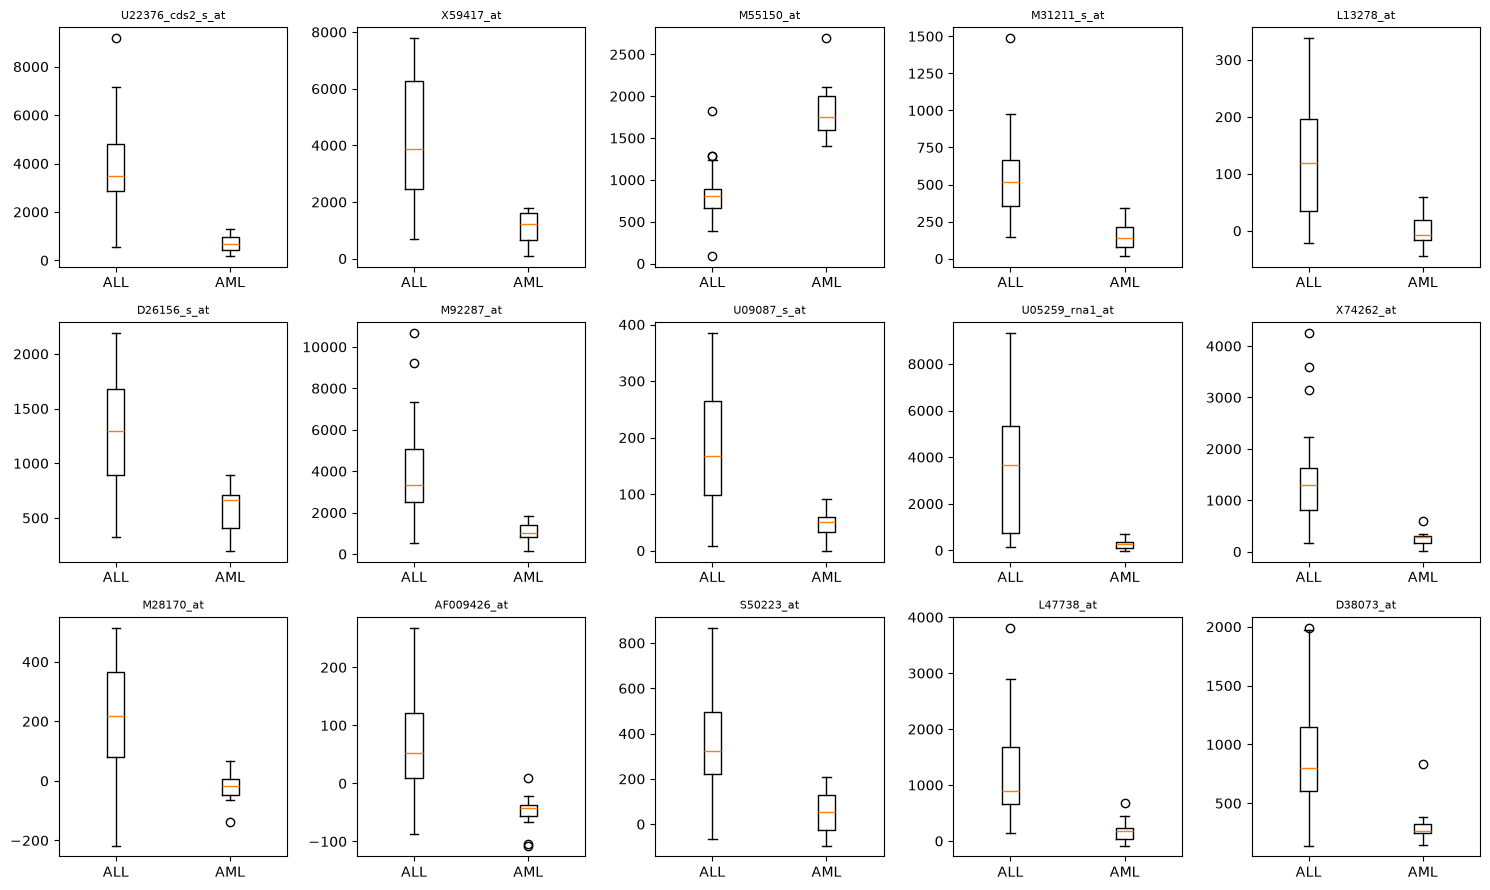

In [18]:
#Boxplots
genes_top15 = df_ttest_ordenado['gen'].head(15).tolist()
boxplots_genes_por_clase(genes_top15, df_expr_train, df_etiquetas)

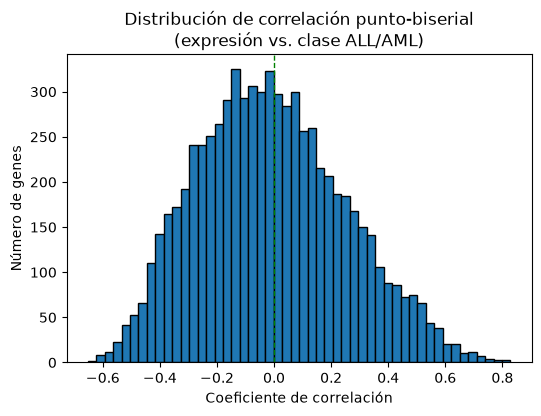

In [19]:
#Para visualización realizamos correlación punto-biserial

# Codificamos la clase como 0 y 1 para correlación 
etiquetas_train = df_etiquetas.set_index('patient').loc[df_expr_train_idx.index, 'cancer']
clase_binaria = (etiquetas_train == 'AML').astype(int)  # ALL=0, AML=1

correlaciones = df_expr_train_idx.corrwith(clase_binaria)

plt.figure(figsize=(6, 4))
plt.hist(correlaciones, bins=50, edgecolor='black')
plt.axvline(0, color='green', linestyle='--', linewidth=1)
plt.title('Distribución de correlación punto-biserial\n(expresión vs. clase ALL/AML)')
plt.xlabel('Coeficiente de correlación')
plt.ylabel('Número de genes')
plt.show()

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"> </span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">3. Transformación</span></div>

## Decisiones de transformación

- **Selección de features:** se replica el criterio del artículo de Golub et 
  al. (1999):  se seleccionan **50 genes** (25 con t-estadístico más 
  positivo, asociados a ALL, y 25 con t-estadístico más negativo, asociados 
  a AML), en lugar de usar los 7129 genes completos. Esta selección se 
  basa en el t-test de Welch calculado durante el EDA.

- **Escalado StandardScaler (para PCA y t-SNE):** se estandarizan los 
  datos (media 0, varianza 1) antes de aplicar PCA y t-SNE, dado que el EDA 
  mostró diferencias de escala muy grandes entre genes (algunos con 
  desviación estándar 50, otros 3000).

- **Escalado MinMaxScaler (para NMF):** NMF requiere valores no 
  negativos, y los datos de expresión ya contienen valores negativos de 
  origen. Por ello, para NMF se usará MinMaxScaler.

- **Manejo de las columnas call:** no se incluyen como input numérico de 
  PCA/NMF/t-SNE, ya que son categóricas (P/A/M) y representan la 
  confiabilidad técnica de la medición, no información genética en sí. Se 
  conservan por separado (df_calls_train, df_calls_indep) como 
  referencia diagnóstica disponible para consultarse ante valores atípicos, 
  sin descartar ninguna información génica.

- **Sin eliminación de genes por limpieza:** no se descartan genes por 
  valores atípicos o negativos, estos se consideran parte de la señal 
  biológica/técnica del dataset, y su tratamiento se resuelve mediante el 
  escalado apropiado para cada algoritmo, no mediante remoción de datos.

In [20]:
#Selección de los 50 genes más correlacionados 
# 25 genes más asociados a ALL (t_stat más positivo) y 25 más asociados a AML (t_stat más negativo)
genes_all_top25 = df_ttest_ordenado.sort_values('t_stat', ascending=False).head(25)
genes_aml_top25 = df_ttest_ordenado.sort_values('t_stat', ascending=True).head(25)

genes_seleccionados = pd.concat([genes_all_top25, genes_aml_top25])['gen'].tolist()

print(len(genes_seleccionados))  # esperado: 50

# Matrices de expresión reducidas a estos 50 genes
df_expr_train_50 = df_expr_train[genes_seleccionados]
df_expr_indep_50 = df_expr_indep[genes_seleccionados]

print(df_expr_train_50.shape)   # (38, 50)
print(df_expr_indep_50.shape)   # (34, 50)

50
(38, 50)
(34, 50)


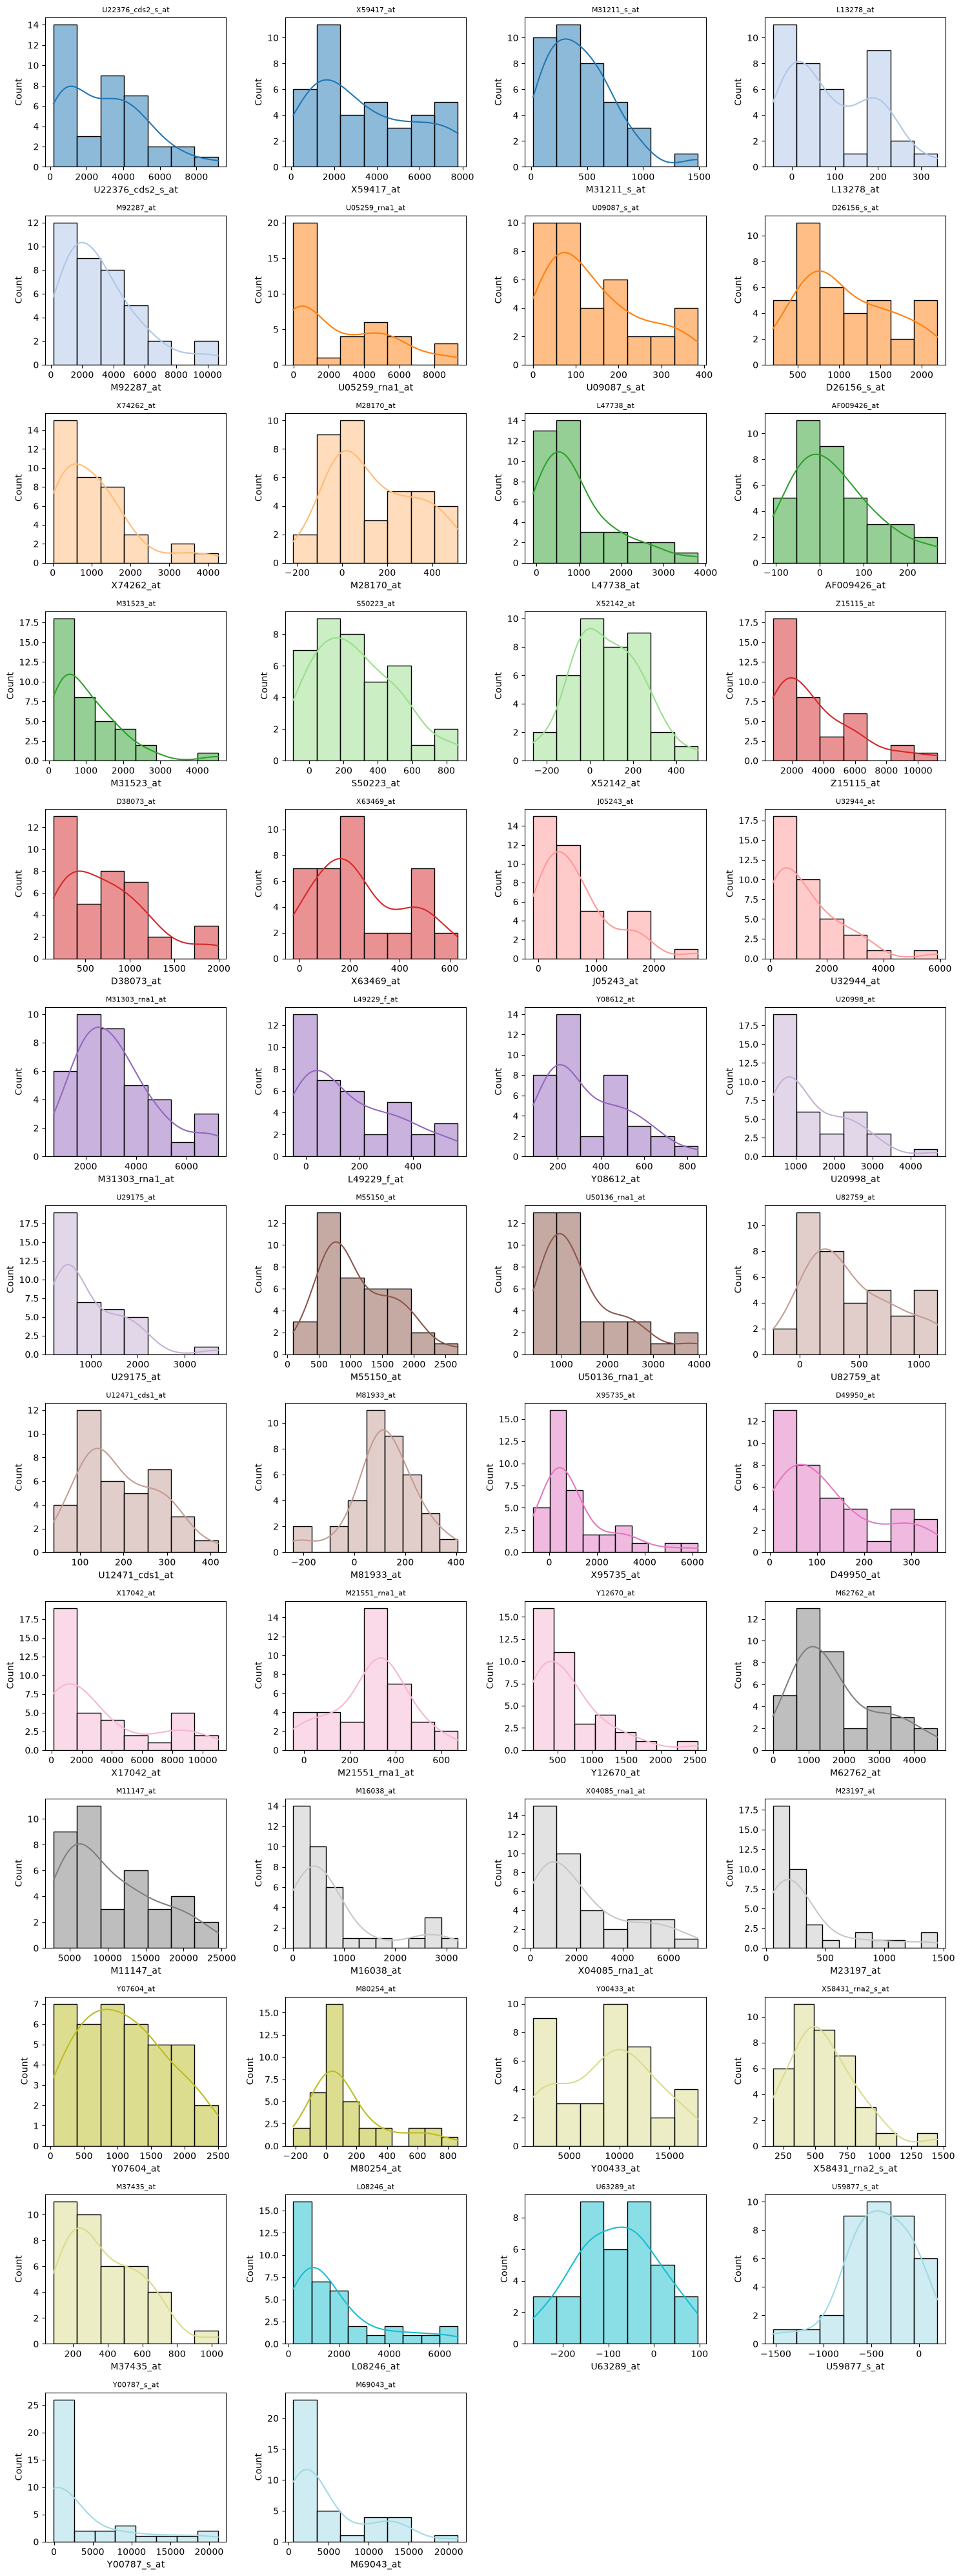

In [21]:
#Visualización de distribuciones de 50 genes 
colores = cm.tab20(np.linspace(0, 1, len(df_expr_train_50.columns)))

plt.figure(figsize=(15, 40))
for i, col in enumerate(df_expr_train_50.columns, 1):
    plt.subplot(13, 4, i)
    plt.title(col, fontsize=8)
    sns.histplot(df_expr_train_50[col], kde=True, color=colores[i-1])
plt.tight_layout()
plt.show()

Observaciones: 

La mayoría de los genes muestran **sesgo hacia la derecha** y algunos muestran **bimodalidad visible** (ej. L13278_at, X63469_at, M55150_at, lo cual es esperable en genes altamente discriminantes. Lo que nos hace sugerir como hipótesis que los dos picos probablemente corresponden a las distribuciones separadas de ALL y AML dentro del mismo histograma 


In [22]:
df_expr_train_50.index = df_expr_train_50.index.astype(int)
df_expr_indep_50.index = df_expr_indep_50.index.astype(int)

In [37]:
#Escalado de los datos para PCA, t-SNE y NMF
# Escalado para PCA y t-SNE 
scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(df_expr_train_50)
X_indep_std = scaler_std.transform(df_expr_indep_50)

df_train_std = pd.DataFrame(X_train_std, columns=df_expr_train_50.columns, index=df_expr_train_50.index)
df_indep_std = pd.DataFrame(X_indep_std, columns=df_expr_indep_50.columns, index=df_expr_indep_50.index)

# Escalado para NMF 
scaler_mm = MinMaxScaler()

X_train_mm = scaler_mm.fit_transform(df_expr_train_50)
X_indep_mm = np.clip(scaler_mm.transform(df_expr_indep_50), 0, 1)  # <- clip agregado aquí

df_train_mm = pd.DataFrame(X_train_mm, columns=df_expr_train_50.columns, index=df_expr_train_50.index)
df_indep_mm = pd.DataFrame(X_indep_mm, columns=df_expr_indep_50.columns, index=df_expr_indep_50.index)

print(df_train_mm.shape, df_indep_mm.shape)

(38, 50) (34, 50)


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">4. Aplicación de Algoritmos </span></div>

### PCA 

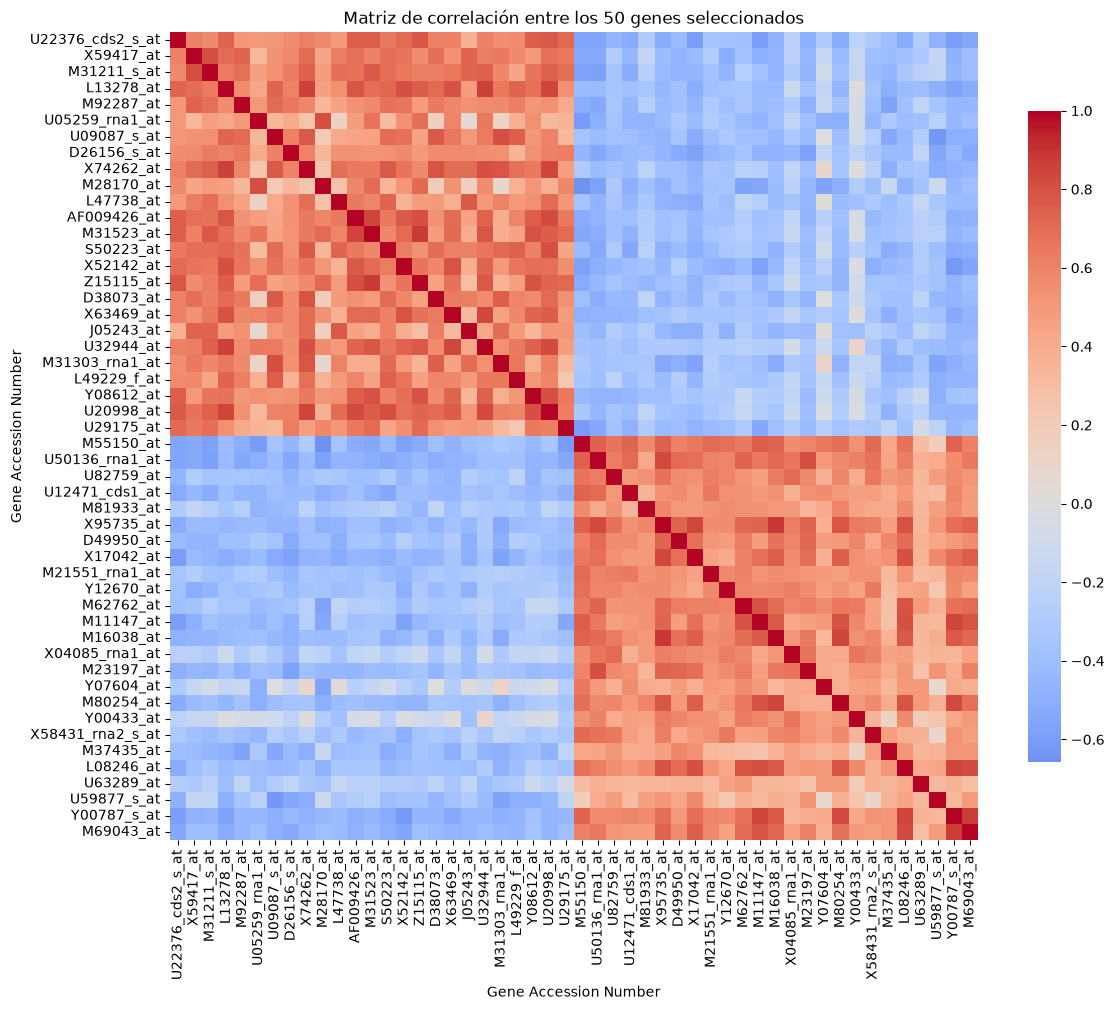

In [38]:
#Matriz de correlación para PCA 
plt.figure(figsize=(12, 10))
matriz_corr = df_train_std.corr()
sns.heatmap(matriz_corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación entre los 50 genes seleccionados')
plt.tight_layout()
plt.show()

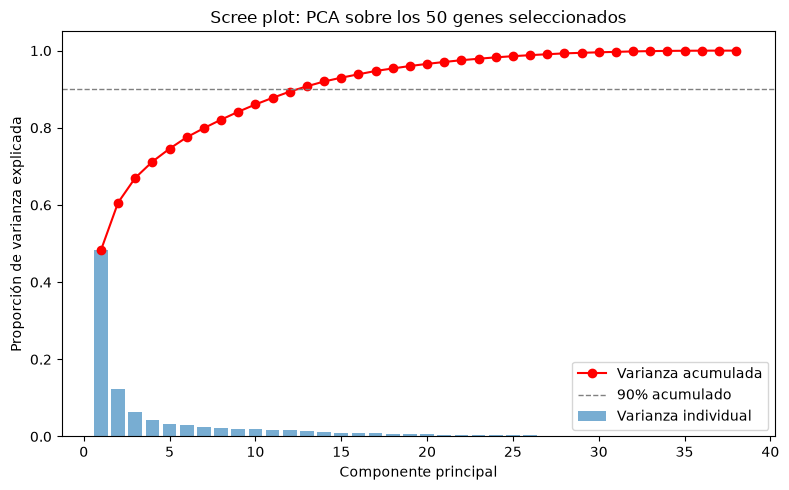

[0.48259174 0.12357799 0.06409916 0.04207133 0.03354692]
[0.48259174 0.60616973 0.67026888 0.71234021 0.74588713]


In [39]:
#Aplicación de PCA 

pca_full = PCA()
pca_full.fit(df_train_std)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual')
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='red', label='Varianza acumulada')
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1, label='90% acumulado')
plt.xlabel('Componente principal')
plt.ylabel('Proporción de varianza explicada')
plt.title('Scree plot: PCA sobre los 50 genes seleccionados')
plt.legend()
plt.tight_layout()
plt.show()

print(varianza_explicada[:5])
print(varianza_acumulada[:5])

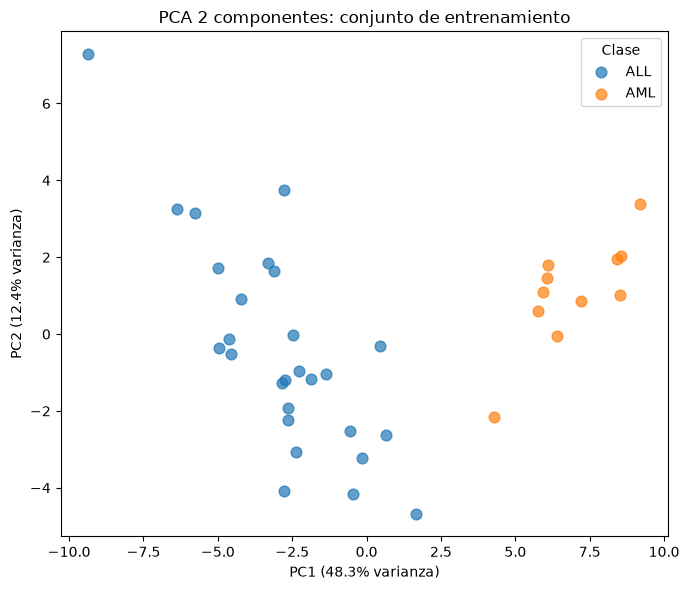

In [26]:
# PCA con 2 componentes para visualización. Las 13 componentes necesarias serán para clasificación. 
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(df_train_std)

df_pca_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'], index=df_train_std.index)
df_pca_2d = df_pca_2d.merge(df_etiquetas, left_index=True, right_on='patient')

plt.figure(figsize=(7, 6))
for clase in df_pca_2d['cancer'].unique():
    subset = df_pca_2d[df_pca_2d['cancer'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'], label=clase, alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('PCA 2 componentes: conjunto de entrenamiento')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

In [30]:
#PCA 3D interactivo 
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(df_train_std)

df_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'], index=df_train_std.index)
df_pca_3d = df_pca_3d.merge(df_etiquetas, left_index=True, right_on='patient')

fig = px.scatter_3d(
    df_pca_3d, x='PC1', y='PC2', z='PC3', color='cancer',
    title='PCA 3 componentes: conjunto de entrenamiento'
)
fig.show()

## Observaciones PCA 

1. **Matriz de correlación cpn 50 genes seleccionados**

- Se observa un patrón claro de **dos bloques**: los 25 genes asociados a 
  ALL están fuertemente correlacionados entre sí (correlación positiva 
  alta), lo mismo ocurre entre los 25 genes asociados a AML; entre ambos 
  bloques la correlación es negativa.
- Este patrón es resultado esperado de la selección vía t-test: al elegir 
  genes por su asociación con una misma clase, se agrupan genes que se 
  mueven de forma similar 

2. **Scree plot**

- **PC1 explica por el 48.3%** de la varianza total; PC2 añade un 
  12.4% adicional (acumulado 0.6%); PC3 aporta 6.4% más (67%).
- Se requieren aproximadamente **13 componentes para alcanzar el 90%** de 
  varianza acumulada.

3.  **Visualización 2D y 3D (PC1, PC2, PC3): conjunto de entrenamiento**

- Ambas visualizaciones muestran una **separación clara entre ALL y AML**, 
  principalmente explicada por PC1: los pacientes AML se ubican 
  consistentemente hacia valores altos de PC1, y los ALL hacia valores 
  bajos, con mínima superposición.
- Este resultado confirma, de forma visual y cuantitativa, que los 50 
  genes seleccionados mediante t-test capturan efectivamente la 
  estructura de separación entre clases, replicando los resultados utilizados también en el 
  predictor del artículo de Golub et al. (1999), aunque con una técnica 
  distinta (PCA en lugar de votos ponderados).

### NMF 


c:\Users\Equipo\miniconda3\envs\cancer-clasif\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Equipo\miniconda3\envs\cancer-clasif\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Equipo\miniconda3\envs\cancer-clasif\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Equipo\miniconda3\envs\cancer-clasif\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\Equipo\miniconda3\envs\cancer-clasif\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number o

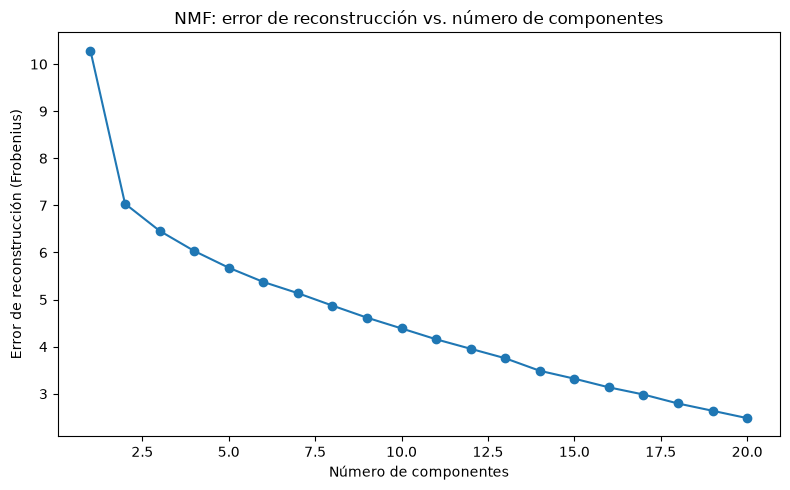

In [41]:
#Vemos componentes necesarias 

errores = []
rango_componentes = range(1, 21)

for k in rango_componentes:
    modelo = NMF(n_components=k, init='nndsvda', random_state=42, max_iter=1000)
    modelo.fit(df_train_mm)
    errores.append(modelo.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(rango_componentes, errores, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Error de reconstrucción (Frobenius)')
plt.title('NMF: error de reconstrucción vs. número de componentes')
plt.tight_layout()
plt.show()

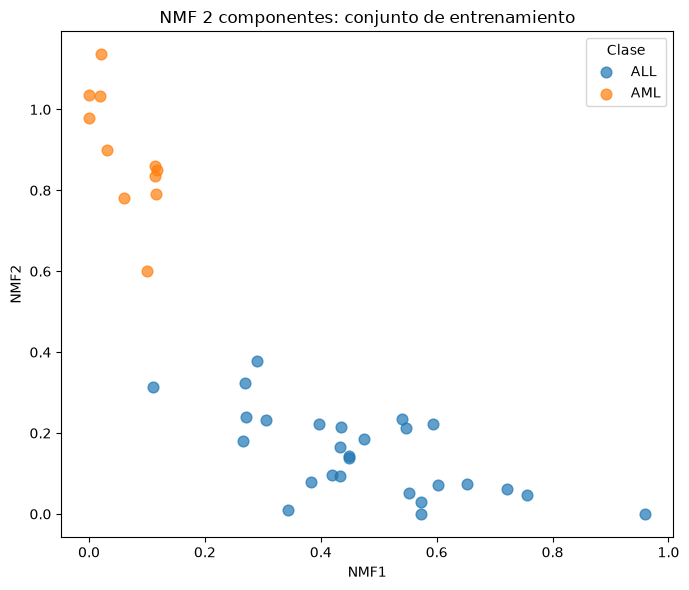

In [42]:
# NMF con 2 componentes para  visualización 
nmf_2d = NMF(n_components=2, init='nndsvda', random_state=42, max_iter=1000)
X_nmf_2d = nmf_2d.fit_transform(df_train_mm)

df_nmf_2d = pd.DataFrame(X_nmf_2d, columns=['NMF1', 'NMF2'], index=df_train_mm.index)
df_nmf_2d = df_nmf_2d.merge(df_etiquetas, left_index=True, right_on='patient')

plt.figure(figsize=(7, 6))
for clase in df_nmf_2d['cancer'].unique():
    subset = df_nmf_2d[df_nmf_2d['cancer'] == clase]
    plt.scatter(subset['NMF1'], subset['NMF2'], label=clase, alpha=0.7, s=60)

plt.xlabel('NMF1')
plt.ylabel('NMF2')
plt.title('NMF 2 componentes: conjunto de entrenamiento')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

In [43]:
#Para clasificador
#NMF con 13 componentes
nmf_13 = NMF(n_components=13, init='nndsvda', random_state=42, max_iter=1000)

X_train_nmf13 = nmf_13.fit_transform(df_train_mm)
X_indep_nmf13 = nmf_13.transform(df_indep_mm)

df_train_nmf13 = pd.DataFrame(
    X_train_nmf13,
    columns=[f'NMF{i+1}' for i in range(13)],
    index=df_train_mm.index
)
df_indep_nmf13 = pd.DataFrame(
    X_indep_nmf13,
    columns=[f'NMF{i+1}' for i in range(13)],
    index=df_indep_mm.index
)

print(df_train_nmf13.shape, df_indep_nmf13.shape)

(38, 13) (34, 13)


 Observaciones

1. **Error de reconstrucción y número de componentes**
- Se calculó el error de reconstrucción (norma de Frobenius) para NMF con 
  1 a 20 componentes sobre df_train_mm (datos escalados con 
  MinMaxScaler, requerido por NMF al no admitir valores negativos).
- La curva muestra una caída pronunciada entre 1 y 2 componentes, seguida 
  de un descenso más gradual. A diferencia del scree plot de PCA (con un 
  codo muy marcado en PC1), el cambio de pendiente es más sutil y 
  ocurre alrededor de la componente **12-13**: antes de ese 
  punto la reducción de error por componente es mayor, después se vuelve 
  aproximadamente constante.

2.  **Valores negativos al transformar el conjunto independiente**

- Al aplicar scaler_mm.transform() (ajustado solo con el conjunto de 
  entrenamiento) sobre el conjunto independiente, algunos genes en este 
  último presentaron valores fuera del rango [mínimo, máximo] observado en 
  entrenamiento, generando valores negativos. Por tanto se recortaron los valores transformados 
  del conjunto independiente al rango [0, 1] antes de pasarlos a NMF, 
  preservando la validez del método sin alterar el ajuste original hecho 
  con el conjunto de entrenamiento.

3. **Visualización**

- El scatter de dos componentes NMF1 vs NMF2 muestra una separación clara entre ALL y AML
- **NMF con 13 componentes** (para uso posterior en clasificador): se 
  generaron df_train_nmf13  y df_indep_nmf13, aplicando 
  el mismo criterio de número de componentes usado en PCA (90% de varianza 
  acumulada), para mantener comparabilidad entre ambos métodos. 

### TSNE

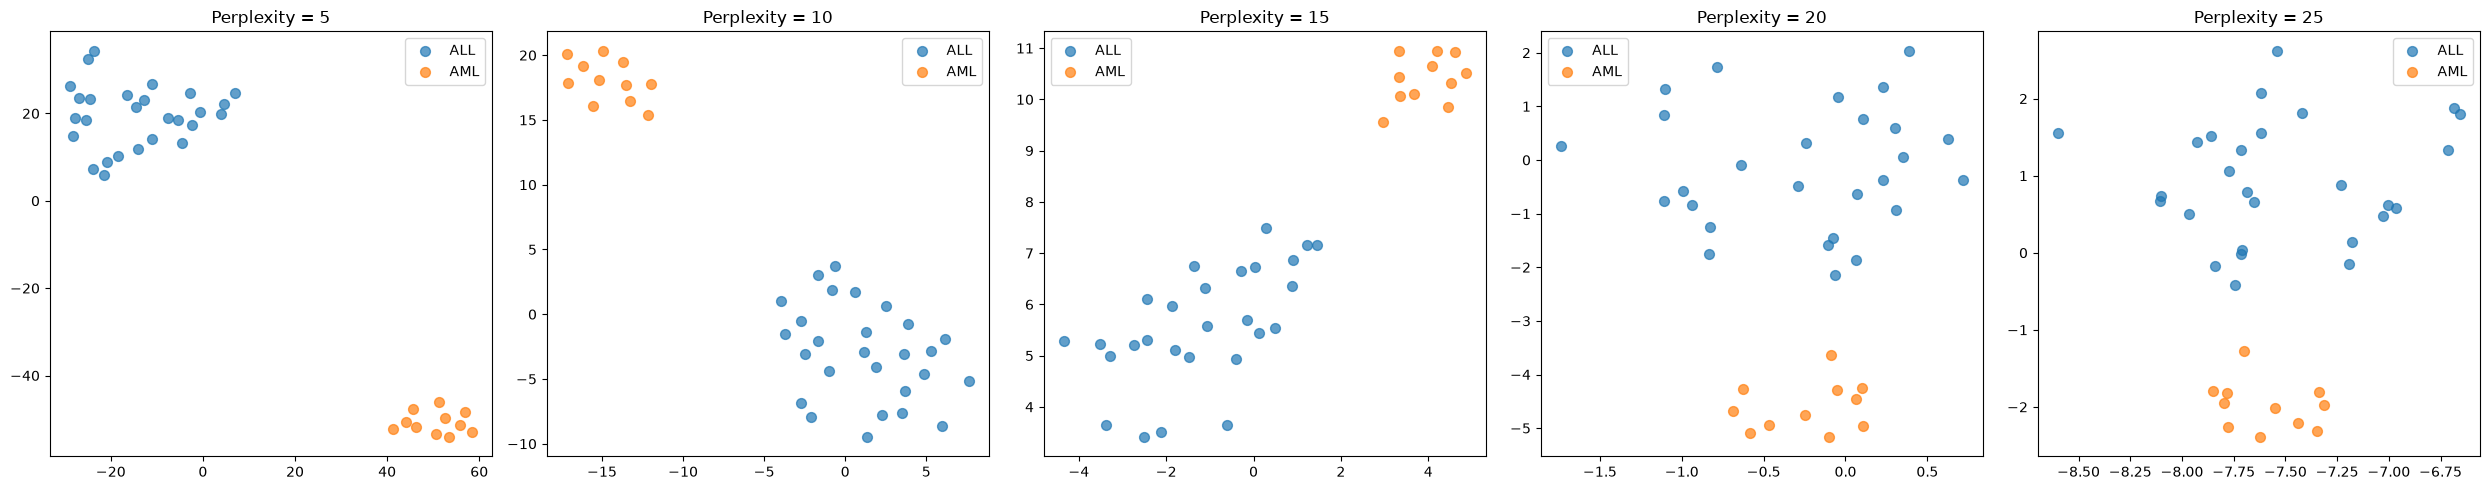

In [45]:
#Observamos diferentes valores de perplexity 

valores_perplexity = [5, 10, 15, 20, 25]

fig, axes = plt.subplots(1, len(valores_perplexity), figsize=(5 * len(valores_perplexity), 5))

for ax, perp in zip(axes, valores_perplexity):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca')
    X_tsne = tsne.fit_transform(df_train_std)

    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=df_train_std.index)
    df_tsne = df_tsne.merge(df_etiquetas, left_index=True, right_on='patient')

    for clase in df_tsne['cancer'].unique():
        subset = df_tsne[df_tsne['cancer'] == clase]
        ax.scatter(subset['TSNE1'], subset['TSNE2'], label=clase, alpha=0.7, s=50)

    ax.set_title(f'Perplexity = {perp}')
    ax.legend()

plt.tight_layout()
plt.show()

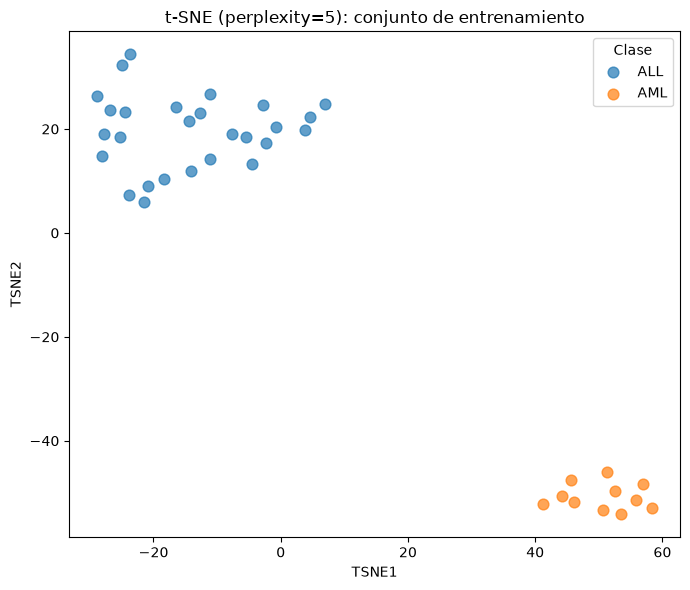

In [49]:
#TSNE con la mejor perplexity observada
tsne_final = TSNE(n_components=2, perplexity=5, random_state=42, init='pca')
X_tsne_final = tsne_final.fit_transform(df_train_std)

df_tsne_final = pd.DataFrame(X_tsne_final, columns=['TSNE1', 'TSNE2'], index=df_train_std.index)
df_tsne_final = df_tsne_final.merge(df_etiquetas, left_index=True, right_on='patient')

plt.figure(figsize=(7, 6))
for clase in df_tsne_final['cancer'].unique():
    subset = df_tsne_final[df_tsne_final['cancer'] == clase]
    plt.scatter(subset['TSNE1'], subset['TSNE2'], label=clase, alpha=0.7, s=60)

plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.title('t-SNE (perplexity=5): conjunto de entrenamiento')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

In [48]:
tsne_3d = TSNE(n_components=3, perplexity=5, random_state=42, init='pca')
X_tsne_3d = tsne_3d.fit_transform(df_train_std)

df_tsne_3d = pd.DataFrame(X_tsne_3d, columns=['TSNE1', 'TSNE2', 'TSNE3'], index=df_train_std.index)
df_tsne_3d = df_tsne_3d.merge(df_etiquetas, left_index=True, right_on='patient')

fig = px.scatter_3d(
    df_tsne_3d, x='TSNE1', y='TSNE2', z='TSNE3', color='cancer',
    title='t-SNE 3D conjunto de entrenamiento'
)
fig.show()

**t-SNE. Observaciones**

- Se probaron valores de perplexity de 5, 10, 15, 20 y 25 sobre 
  df_train_std (38 muestras), con init='pca' para mayor estabilidad 
  dado el tamaño pequeño de muestra.
- **Perplexity=5 produjo la separación más clara y compacta** entre ALL y 
  AML, con dos clusters, por dicha razón se escogió este valor. 


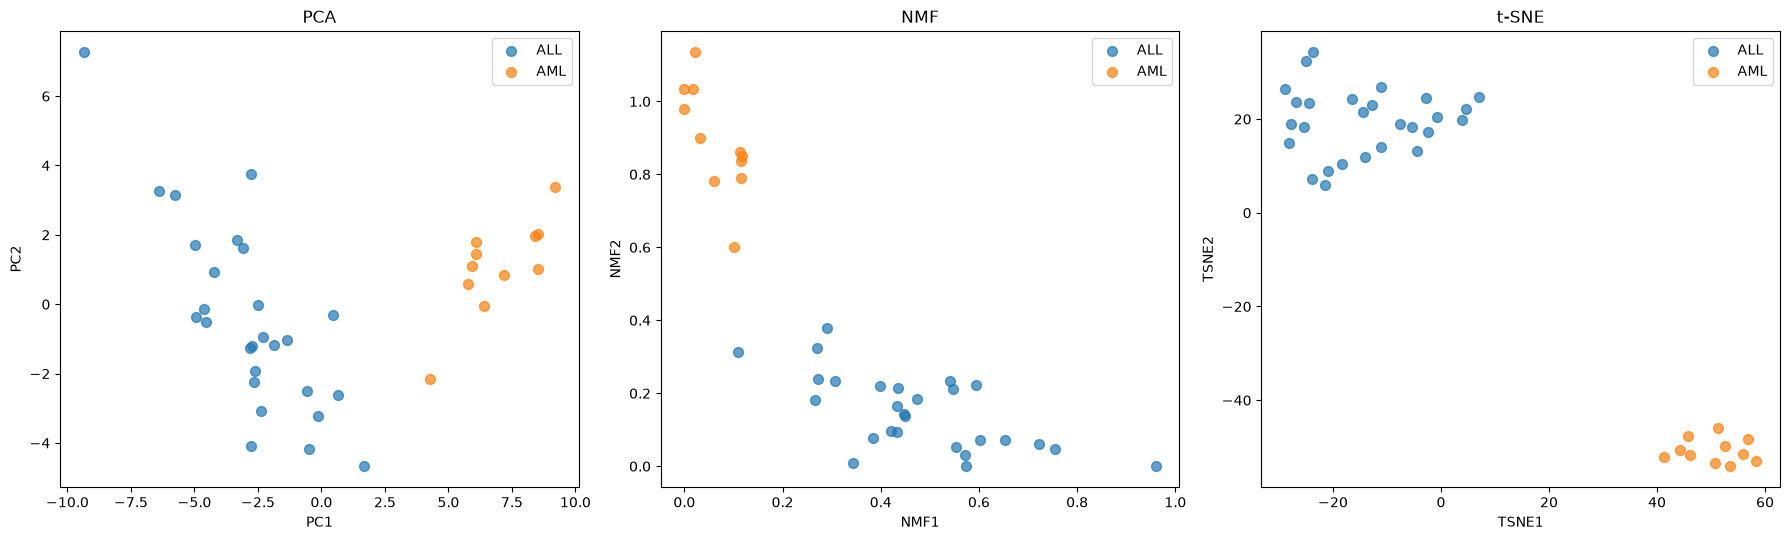

In [50]:
# Comparación de métodos 
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

datasets_2d = {
    'PCA': (df_pca_2d, 'PC1', 'PC2'),
    'NMF': (df_nmf_2d, 'NMF1', 'NMF2'),
    't-SNE': (df_tsne_final, 'TSNE1', 'TSNE2'),
}

for ax, (nombre, (df_metodo, col_x, col_y)) in zip(axes, datasets_2d.items()):
    for clase in df_metodo['cancer'].unique():
        subset = df_metodo[df_metodo['cancer'] == clase]
        ax.scatter(subset[col_x], subset[col_y], label=clase, alpha=0.7, s=50)
    ax.set_title(nombre)
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.legend()

plt.tight_layout()
plt.show()

In [52]:
#Silhouette score para PCA, NMF y t-SNE

etiquetas_binarias = (df_pca_2d.set_index('patient')['cancer'] == 'AML').astype(int)

sil_pca = silhouette_score(df_pca_2d[['PC1', 'PC2']], etiquetas_binarias.values)
sil_nmf = silhouette_score(df_nmf_2d[['NMF1', 'NMF2']], etiquetas_binarias.values)
sil_tsne = silhouette_score(df_tsne_final[['TSNE1', 'TSNE2']], etiquetas_binarias.values)

df_silhouette = pd.DataFrame({
    'Método': ['PCA', 'NMF', 't-SNE'],
    'Silhouette Score': [sil_pca, sil_nmf, sil_tsne]
}).sort_values('Silhouette Score', ascending=False)

display(df_silhouette)

,Método,Silhouette Score
2,t-SNE,0.851410
1,NMF,0.719224
0,PCA,0.627277


In [54]:
#última métrica: trustworthiness

#usamos 5  n_neighbors, consistente con la perplexity elegida en t-SNE
trust_pca = trustworthiness(df_train_std, df_pca_2d[['PC1', 'PC2']], n_neighbors=5)
trust_nmf = trustworthiness(df_train_mm, df_nmf_2d[['NMF1', 'NMF2']], n_neighbors=5)
trust_tsne = trustworthiness(df_train_std, df_tsne_final[['TSNE1', 'TSNE2']], n_neighbors=5)

df_trust = pd.DataFrame({
    'Método': ['PCA', 'NMF', 't-SNE'],
    'Trustworthiness': [trust_pca, trust_nmf, trust_tsne]
}).sort_values('Trustworthiness', ascending=False)

display(df_trust)

,Método,Trustworthiness
2,t-SNE,0.926491
0,PCA,0.907368
1,NMF,0.897018


 **Comparación PCA vs. NMF vs. t-SNE**


- Los tres métodos logran separar visualmente ALL de AML en el espacio 
  reducido, pero con distinta claridad: t-SNE presenta la separación más 
  nítida y compacta, seguido de PCA, y luego NMF.
- t-SNE obtiene el score más alto en Silhouette score, consistente con su tendencia  a 
  formar clusters compactos y bien separados
- En cuanto a Trustworthiness (fidelidad de la reducción respecto al espacio original) los tres métodos muestran valores altos y relativamente cercanos entre sí (diferencia de 3 puntos porcentuales), lo que indica que todos 
  preservan razonablemente bien las relaciones de vecindad del espacio 
  original de 50 genes, sin embargo, t-SNE también tiene el score más alto. 


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">5. Clasificadores </span></div>

In [56]:
# PCA con 13 componentes (fit en train, transform en independiente)
pca_13 = PCA(n_components=13)
X_train_pca13 = pca_13.fit_transform(df_train_std)
X_indep_pca13 = pca_13.transform(df_indep_std)

df_train_pca13 = pd.DataFrame(X_train_pca13, columns=[f'PC{i+1}' for i in range(13)], index=df_train_std.index)
df_indep_pca13 = pd.DataFrame(X_indep_pca13, columns=[f'PC{i+1}' for i in range(13)], index=df_indep_std.index)

# Etiquetas alineadas con cada índice de paciente
y_train = df_etiquetas.set_index('patient').loc[df_train_std.index, 'cancer']
y_indep = df_etiquetas.set_index('patient').loc[df_indep_std.index, 'cancer']

In [60]:
#Modelos: SVM, Regresión logística y KNN 
from sklearn.neighbors import KNeighborsClassifier

modelos = {
    'SVM lineal': SVC(kernel='linear', random_state=42),
    'Regresión Logística': LogisticRegression(max_iter=5000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
}

resultados = []

for nombre_rep, (X_train, X_indep) in representaciones.items():
    for nombre_modelo, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_indep)

        acc = accuracy_score(y_indep, y_pred)
        f1 = f1_score(y_indep, y_pred, pos_label='AML')

        resultados.append({
            'Representación': nombre_rep,
            'Modelo': nombre_modelo,
            'Accuracy': acc,
            'F1 (AML)': f1
        })

df_resultados = pd.DataFrame(resultados).sort_values('Accuracy', ascending=False)
display(df_resultados)


,Representación,Modelo,Accuracy,F1 (AML)
8,NMF-13,KNN (k=5),0.970588,0.965517
0,50 genes (escalados),SVM lineal,0.941176,0.923077
3,PCA-13,SVM lineal,0.941176,0.923077
2,50 genes (escalados),KNN (k=5),0.911765,0.880000
1,50 genes (escalados),Regresión Logística,0.911765,0.880000
4,PCA-13,Regresión Logística,0.911765,0.880000
5,PCA-13,KNN (k=5),0.882353,0.833333
6,NMF-13,SVM lineal,0.794118,0.666667
7,NMF-13,Regresión Logística,0.617647,0.133333


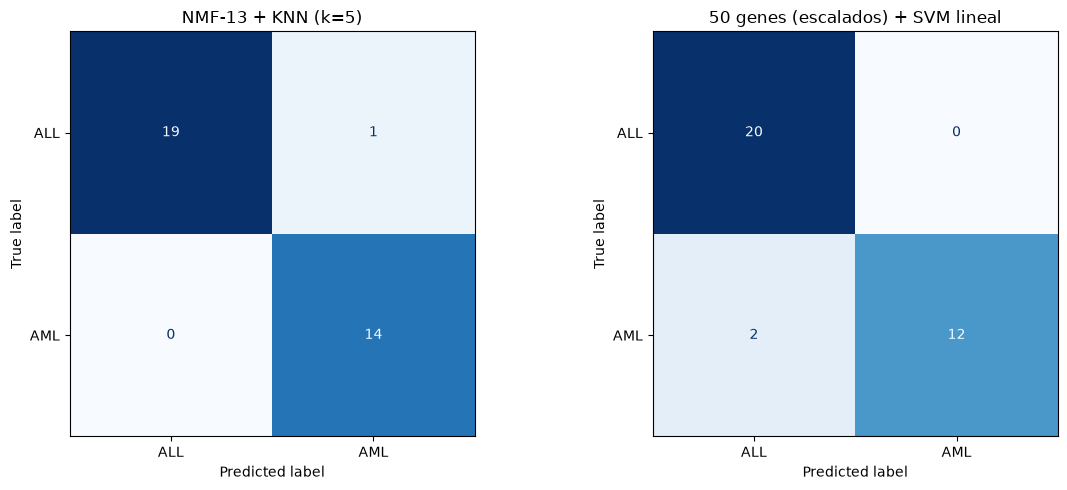

In [62]:
#Matriz de confusión
fig, axes = plt.subplots(1, len(mejores_combos), figsize=(6 * len(mejores_combos), 5))

for ax, (nombre_rep, nombre_modelo, X_train, X_indep, modelo) in zip(axes, mejores_combos):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_indep)
    ConfusionMatrixDisplay.from_predictions(y_indep, y_pred, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre_rep} + {nombre_modelo}')

plt.tight_layout()
plt.show()

In [67]:
#Tabla resumen 
resultados_clasificacion = pd.DataFrame([
    ["NMF-13", "KNN (k=5)", "0.971", "0.966"],
    ["50 genes (escalados)", "SVM lineal", "0.941", "0.923"],
    ["PCA-13", "SVM lineal", "0.941", "0.923"],
    ["50 genes (escalados)", "Regresión Logística", "0.912", "0.880"],
    ["PCA-13", "Regresión Logística", "0.912", "0.880"],
    ["PCA-13", "KNN (k=5)", "0.882", "0.833"],
    ["NMF-13", "SVM lineal", "0.794", "0.667"],
    ["NMF-13", "Regresión Logística", "0.618", "0.133"],
], columns=["Representación", "Modelo", "Accuracy", "F1 (AML)"])

resultados_clasificacion.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}) \
    .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("background-color", "#4C72B0"), ("color", "white")]}]) \
    .hide(axis="index")

Representación,Modelo,Accuracy,F1 (AML)
NMF-13,KNN (k=5),0.971,0.966
50 genes (escalados),SVM lineal,0.941,0.923
PCA-13,SVM lineal,0.941,0.923
50 genes (escalados),Regresión Logística,0.912,0.880
PCA-13,Regresión Logística,0.912,0.880
PCA-13,KNN (k=5),0.882,0.833
NMF-13,SVM lineal,0.794,0.667
NMF-13,Regresión Logística,0.618,0.133


**Observaciones de Clasificación: comparación final de modelos y representaciones**


1. **El desempeño depende de la combinación representación y modelo**

- **NMF-13 combinado con KNN (k=5) obtuvo el mejor desempeño global** 
  (accuracy 0.971, F1 0.966), superando incluso a SVM sobre los 50 genes 
  o PCA-13. Esto contrasta con la conclusión inicial de que NMF rinde peor, notando entonces que el desempeño de 
  una representación **no es una propiedad absoluta**, depende
  de qué modelo la utiliza. 

2. **Matrices de confusión**

- **NMF-13 con KNN:** 1 error: un paciente ALL clasificado como AML
- **50 genes con SVM lineal:** 2 errores:dos pacientes AML clasificados 
  como ALL.
.
3. **Nota sobre conocimiento de dominio**

- A diferencia de un escenario de screening (cáncer sí/no), donde 
  convencionalmente se prioriza evitar falsos negativos, este problema 
  distingue entre **dos subtipos de leucemia ya diagnosticada** con lo que no hay una clase sana de referencia.
- Ambas direcciones de error tienen consecuencias clínicas serias: el 
  artículo de Golub et al. señala que los esquemas de tratamiento para 
  ALL y AML son distintos (ALL: corticosteroides, vincristina, 
  metotrexato, L-asparaginasa; AML: daunorubicina y citarabina), y aplicar 
  el tratamiento equivocado reduce las tasas de cura y genera toxicidad 
  innecesaria, independientemente de la dirección del error. Por esta razón, no se prioriza una métrica orientada a un solo tipo de error; se reporta **F1-score** además de 
  accuracy, ya que balancea precisión y recall y es más apropiado dado que 
  ambos tipos de error son clínicamente relevantes.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;"></span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">6. Conclusiones </span></div>


- **Conexión con el artículo de Golub et al. (1999):** el ejercicio 
  replicó la misma lógica central del 
  artículo original: identificar un subconjunto reducido de genes 
  informativos permite distinguir con alta precisión entre ALL y AML, 
  confirmando que la señal biológica reportada en 1999 sigue siendo 
  recuperable sobre el mismo dataset con metodologías distintas a las 
  usadas por los autores.

- **La selección de features fue determinante:** el EDA mostró que, con 
  genes elegidos al azar, no hay separabilidad visible entre clases; en 
  cambio, seleccionar los 50 genes más discriminantes (vía t-test) generó 
  una estructura de correlación en bloques muy clara, que luego se 
  tradujo en separación nítida en PCA, NMF y t-SNE, y en alto desempeño 
  predictivo. Esto confirma que la elección de qué información alimentar 
  a un modelo puede ser más determinante que el modelo o técnica de 
  reducción utilizados.

- **PCA, NMF y t-SNE ofrecen perspectivas complementarias, no 
  intercambiables:** los tres lograron visualizar separación entre 
  clases, pero con propiedades distintas. PCA preserva estructura global 
  y es interpretable como transformación lineal; NMF impone no 
  negatividad y perdió más información en la compresión; t-SNE priorizó estructura local, logrando la mejor 
  separación visual y el mayor trustworthiness, pero sin posibilidad de 
  aplicarse a datos nuevos, lo que lo hizo inviable 
  para la etapa de clasificación.

- **El desempeño de una representación depende del modelo que la usa:** 
  el hallazgo más contraintuitivo del ejercicio fue que NMF-13, la 
  representación con peor desempeño bajo SVM y Regresión Logística, 
  resultó la mejor combinación de todas al emparejarse con KNN. Esto 
  matiza cualquier conclusión sobre los métodos a elegir, por tanto  
  la evaluación debe hacerse sobre la combinación representación y modelo, 
  no sobre cada componente por separado.

- **PCA-13 igualó el desempeño de usar los 50 genes completos**, lo cual 
  es evidencia de que, en este caso, la reducción dimensional no sacrificó 
  información relevante para la tarea: al ser una transformación 
  ortogonal, y dado que la señal discriminante estaba concentrada casi 
  enteramente en PC1, PCA comprimió el problema sin pérdida práctica.

- **La evaluación de errores debe ajustarse al contexto clínico real:** 
  al tratarse de una distinción entre dos subtipos de cáncer ya 
  diagnosticado, no existe una dirección 
  de error "preferible" por defecto, ambos tipos de error tienen consecuencias clínicas serias por la diferencia en 
  esquemas de tratamiento. Esto justificó reportar F1-score además de 
  accuracy como métrica de evaluación.

- **Limitaciones y trabajo futuro:** el tamaño de muestra reducido limita la robustez 
  estadística de las conclusiones y hace sensibles a los modelos frente a 
  hiperparámetros. Quedan como 
  posibles extensiones: validar con validación cruzada en lugar de una 
  sola partición train/independiente, probar transformaciones adicionales sobre la expresión génica, y explorar si la información de las columnas call (confiabilidad de la medición) 
  aporta valor adicional al incorporarse de forma explícita al modelo.